<a href="https://colab.research.google.com/github/rix031110/Projects/blob/main/1.Novel_Food_Business_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [115]:
file_path= '/content/drive/MyDrive/Università/DATA SCIENCE FOR MANAGEMENT UNICATT/Novel_Food_Dataset.xlsx'

In [116]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
df = pd.read_excel(file_path, header=0)

In [118]:
df.head()

,V1,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,Q1_9,...,Q18_6,Q19,Q20,Q21,Q22,Q25,Q27,Q26,Age_groups,Nationality_groups
0,ID_40,9,10,8,10,10,10,6,8,7,...,7,29,1,3,1,4,3,2,1,1
1,ID_50,6,7,8,9,7,8,6,5,4,...,6,29,1,3,1,4,3,2,1,1
2,ID_56,10,9,6,10,9,8,9,10,7,...,4,24,1,3,1,2,1,1,1,1
3,ID_59,8,8,5,9,9,8,8,8,8,...,5,53,2,3,1,2,3,3,4,1
4,ID_64,8,9,5,9,9,8,6,7,9,...,7,53,1,3,1,2,3,5,4,1


In [119]:
used_columns = [
    'Q1_1','Q1_2','Q1_3','Q1_4','Q1_5',
    'Q1_6','Q1_7','Q1_8','Q1_9','Q1_10',
    'Q3',
    'Q5',
    'Q23',
    'Q8',
    'Q13',
    'Q14_1','Q14_2','Q14_3','Q14_4','Q14_5',
    'Q14_6','Q14_7','Q14_8','Q14_9','Q14_10','Q14_11',
    'Q15_1','Q15_2','Q15_3','Q15_4',
    'Q15_5','Q15_6','Q15_7','Q15_8',
    'Q16',
    'Q17_1','Q17_2','Q17_3','Q17_4','Q17_5',
    'Q17_6','Q17_7','Q17_8','Q17_9','Q17_10',
    'Q18_1','Q18_2','Q18_3',
    'Q18_4','Q18_5','Q18_6',
    'Q19','Q20','Q22','Q25','Q27',
    'Q29_1','Q29_2','Q29_3','Q29_4','Q29_5',
    'Q2_3', 'Q2_4', 'Q4'
]

used_columns = [col for col in used_columns if col in df.columns]


df = df[used_columns]


In [120]:
print('===== MISSING VALUES =====')
print(df.isnull().sum())

===== MISSING VALUES =====
Q1_1      0
Q1_2      0
Q1_3      0
Q1_4      0
Q1_5      0
Q1_6      0
Q1_7      0
Q1_8      0
Q1_9      0
Q1_10     0
Q3        0
Q5        0
Q23       0
Q8        0
Q13       0
Q14_1     0
Q14_2     0
Q14_3     0
Q14_4     0
Q14_5     0
Q14_6     0
Q14_7     0
Q14_8     0
Q14_9     0
Q14_10    0
Q14_11    0
Q15_1     0
Q15_2     0
Q15_3     0
Q15_4     0
Q15_5     0
Q15_6     0
Q15_7     0
Q15_8     0
Q16       0
Q17_1     0
Q17_2     0
Q17_3     0
Q17_4     0
Q17_5     0
Q17_6     0
Q17_7     0
Q17_8     0
Q17_9     0
Q17_10    0
Q18_1     0
Q18_2     0
Q18_3     0
Q18_4     0
Q18_5     0
Q18_6     0
Q19       0
Q20       0
Q22       0
Q25       0
Q27       0
Q2_3      0
Q2_4      0
Q4        0
dtype: int64


In [121]:
df

,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,Q1_9,Q1_10,...,Q18_5,Q18_6,Q19,Q20,Q22,Q25,Q27,Q2_3,Q2_4,Q4
0,9,10,8,10,10,10,6,8,7,5,...,7,7,29,1,1,4,3,9,10,2.0
1,6,7,8,9,7,8,6,5,4,5,...,9,6,29,1,1,4,3,6,8,3.0
2,10,9,6,10,9,8,9,10,7,6,...,3,4,24,1,1,2,1,8,9,2.0
3,8,8,5,9,9,8,8,8,8,6,...,2,5,53,2,1,2,3,3,2,0.0
4,8,9,5,9,9,8,6,7,9,9,...,3,7,53,1,1,2,3,6,6,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,1,8,7,9,8,10,2,8,9,1,...,7,6,23,1,8,4,1,1,1,2.0
189,9,8,9,10,7,4,7,9,6,4,...,7,6,25,2,2,3,1,10,3,8.0
190,3,8,6,9,9,7,8,7,9,5,...,2,3,26,2,2,3,1,4,8,2.0
191,8,10,10,10,10,10,8,8,8,7,...,7,7,44,1,1,4,3,1,1,6.0


In [122]:
# Gender
gender_map = {
    1: 'Male',
    2: 'Female'
}

# Area of Origin
origin_map = {
    1: 'Italy',
    2: 'Europe',
    3: 'Asia',
    4: 'North America',
    5: 'South America',
    6: 'Central America',
    7: 'Africa',
    8: 'Oceania'
}

# Education
education_map = {
    1: 'Middle School',
    2: 'High School',
    3: 'Bachelor',
    4: 'Master',
    5: 'PhD'
}

# Occupation
occupation_map = {
    1: 'Student',
    2: 'Part Time',
    3: 'Full Time',
    4: 'Unemployed',
    5: 'Retired'
}

# Apply mappings

df['Q20'] = df['Q20'].map(gender_map)

df['Q22'] = df['Q22'].map(origin_map)

df['Q25'] = df['Q25'].map(education_map)

df['Q27'] = df['Q27'].map(occupation_map)

## Gender Distribution

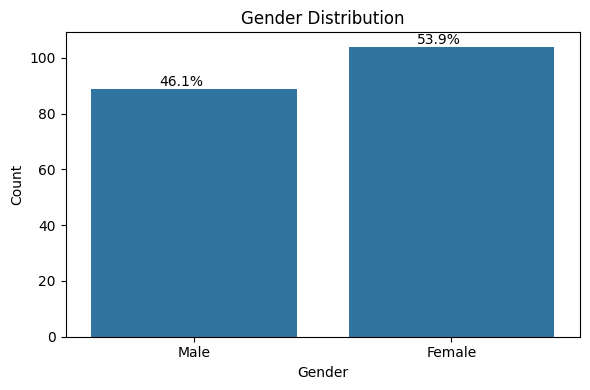

In [123]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Q20')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

total = len(df['Q20'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05 # Adjust x position slightly
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Education Distribution

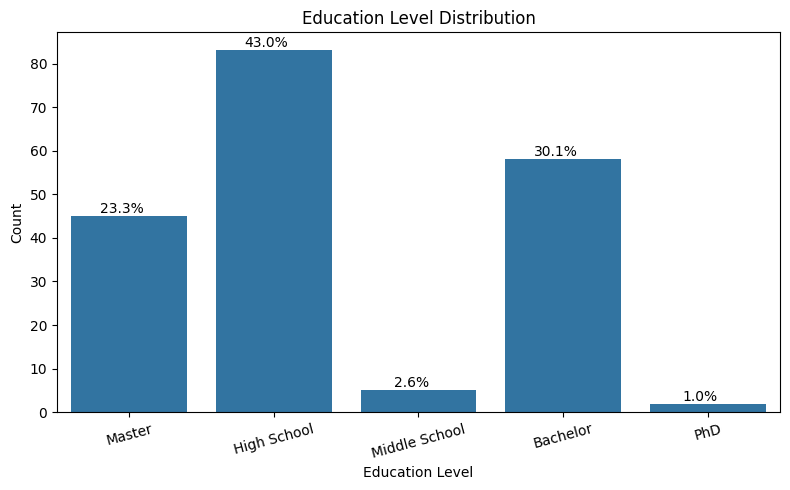

In [124]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Q25')
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=15)

total = len(df['Q25'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05 # Adjust x position slightly
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Occupation Distribution

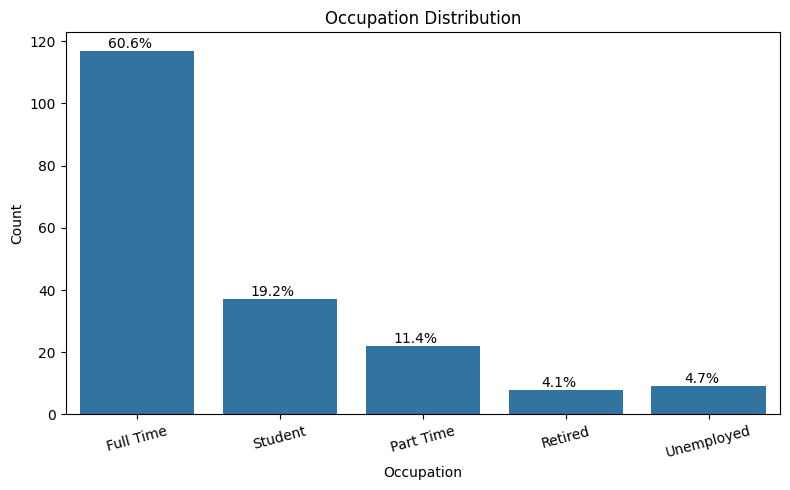

In [125]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Q27')
plt.title('Occupation Distribution')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=15)

total = len(df['Q27'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05 # Adjust x position slightly
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Age Distribution

In [126]:
age_bins = [20, 30, 40, 50, 60]
age_labels = ['20-29', '30-39', '40-49', '50-59']

df['Age_Group'] = pd.cut(
    df['Q19'],
    bins=age_bins,
    labels=age_labels,
    right=False
)


In [127]:
df['Age_Group']

,Age_Group
0,20-29
1,20-29
2,20-29
3,50-59
4,50-59
...,...
188,20-29
189,20-29
190,20-29
191,40-49


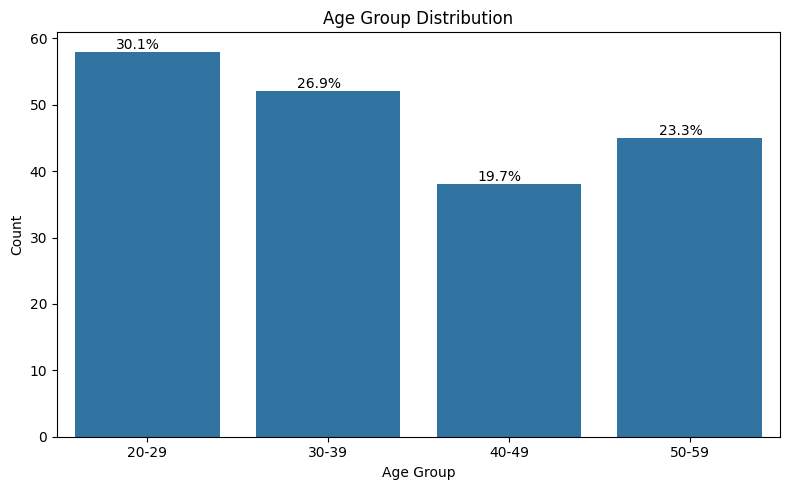

In [128]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Age_Group')

plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')

total = len(df['Age_Group'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05 # Adjust x position slightly
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Area of Origin

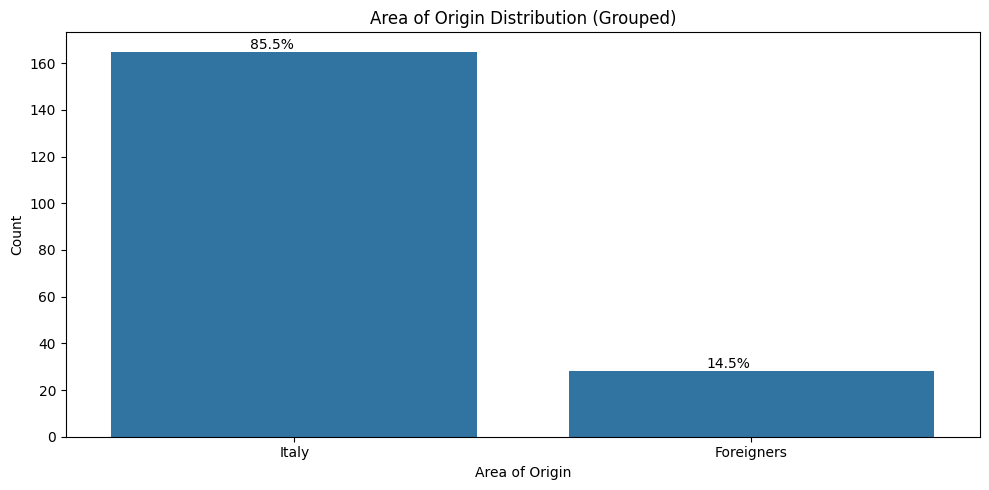

In [129]:
plt.figure(figsize=(10,5))

# Group non-Italy origins into 'Foreigners'
grouped_q22 = df['Q22'].apply(lambda x: 'Italy' if x == 'Italy' else 'Foreigners')

ax = sns.countplot(
    x=grouped_q22,
    order=grouped_q22.value_counts().index
)

plt.title('Area of Origin Distribution (Grouped)')
plt.xlabel('Area of Origin')
plt.ylabel('Count')

total = len(grouped_q22)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.xticks(rotation=0) # No need to rotate for two categories

plt.tight_layout()
plt.show()

# Restaurant Visits per Month

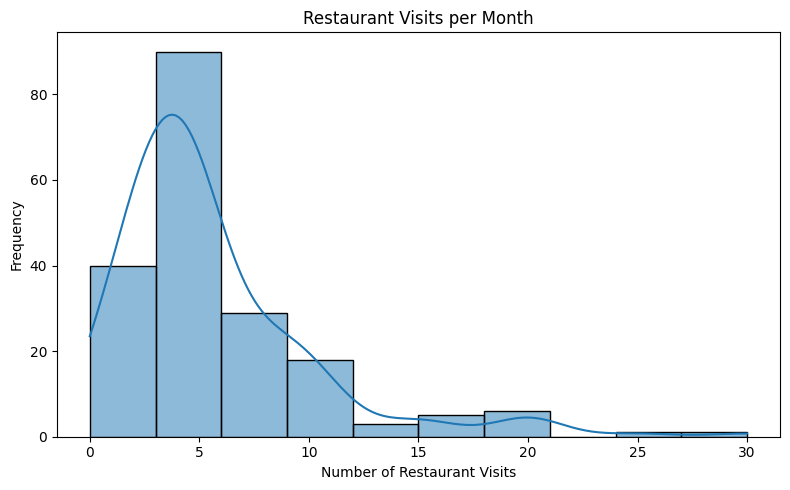

In [130]:
plt.figure(figsize=(8,5))

ax = sns.histplot(df['Q3'], bins=10, kde=True)

plt.title('Restaurant Visits per Month')
plt.xlabel('Number of Restaurant Visits')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Average Spending in International Restaurants

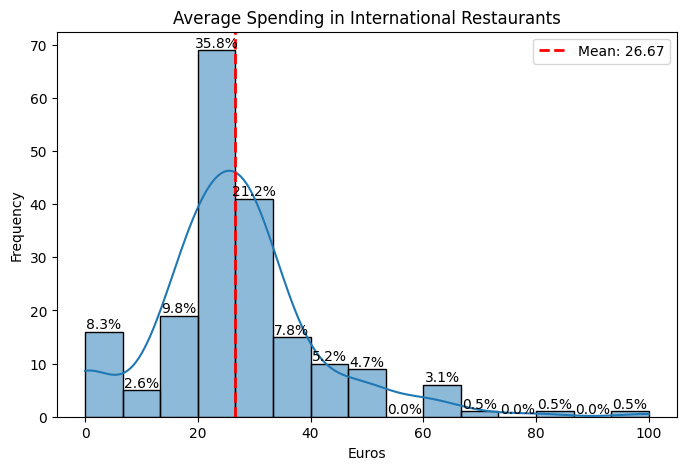

In [131]:
plt.figure(figsize=(8,5))
ax = sns.histplot(df['Q5'], bins=15, kde=True, line_kws={'color': 'red'})
plt.title('Average Spending in International Restaurants')
plt.xlabel('Euros')
plt.ylabel('Frequency')

total_observations = len(df['Q5'])

for p in ax.patches:
    height = p.get_height()
    percentage = '{:.1f}%'.format(100 * height / total_observations)
    # Adjust x position to be in the center of the bar
    x = p.get_x() + p.get_width() / 2
    # Adjust y position slightly above the bar
    y = height # Set y at the top of the bar
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

# Add a red line with the mean value
mean_q5 = df['Q5'].mean()
plt.axvline(mean_q5, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_q5:.2f}')
plt.legend()

plt.show()

# Restaurant Selection Criteria

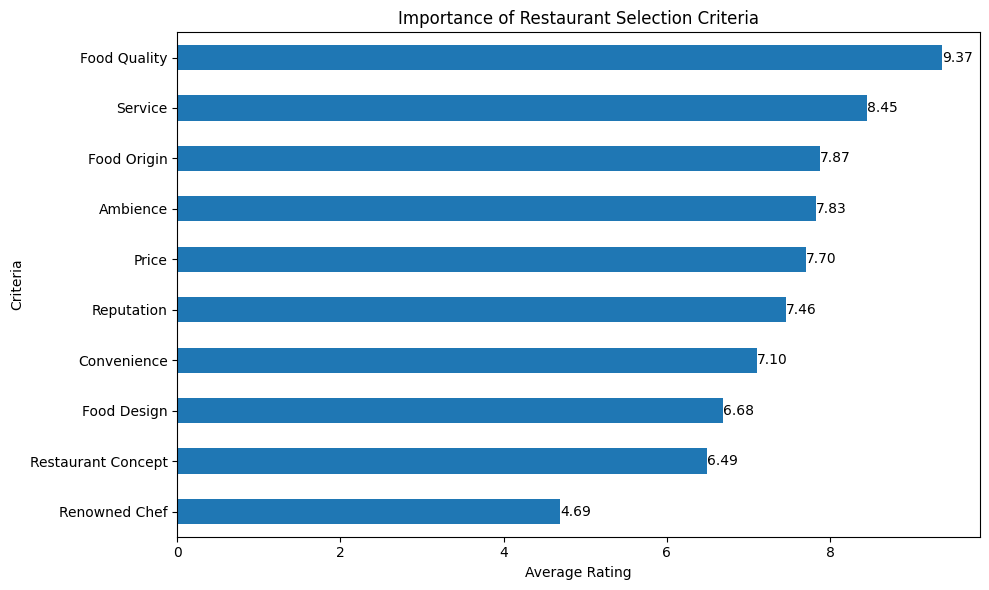

In [132]:
# Q1 labels

q1_labels = {
    'Q1_1': 'Restaurant Concept',
    'Q1_2': 'Ambience',
    'Q1_3': 'Price',
    'Q1_4': 'Food Quality',
    'Q1_5': 'Service',
    'Q1_6': 'Food Origin',
    'Q1_7': 'Convenience',
    'Q1_8': 'Reputation',
    'Q1_9': 'Food Design',
    'Q1_10': 'Renowned Chef'
}

q1_means = df[list(q1_labels.keys())].mean()

q1_means.index = [q1_labels[col] for col in q1_means.index]

q1_means = q1_means.sort_values()


plt.figure(figsize=(10,6))

ax = q1_means.plot(kind='barh')

plt.title('Importance of Restaurant Selection Criteria')
plt.xlabel('Average Rating')
plt.ylabel('Criteria')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

# Awareness of Novel Food



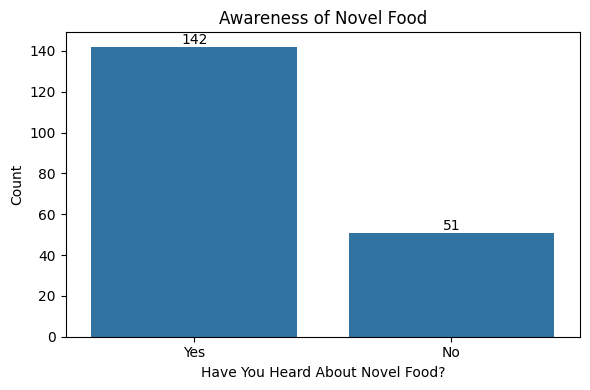

In [133]:
q8_map = {
    1: 'Yes',
    0: 'No'
}

df['Q8_Label'] = df['Q8'].map(q8_map)


plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Q8_Label')

plt.title('Awareness of Novel Food')
plt.xlabel('Have You Heard About Novel Food?')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Willingness to try insects in Milan




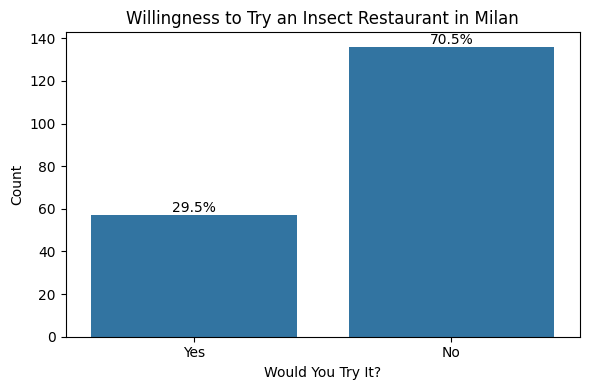

In [134]:
q13_map = {
    1: 'Yes',
    0: 'No'
}

df['Q13_Label'] = df['Q13'].map(q13_map)

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Q13_Label')

plt.title('Willingness to Try an Insect Restaurant in Milan')
plt.xlabel('Would You Try It?')
plt.ylabel('Count')

total = len(df['Q13_Label'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2  # Center x position
    y = p.get_height()  # Position y at the top of the bar
    ax.annotate(percentage, (x, y), ha='center', va='bottom') # Annotate percentage

plt.tight_layout()
plt.show()

# Factors Motivating Consumers to Try an Insect Restaurant

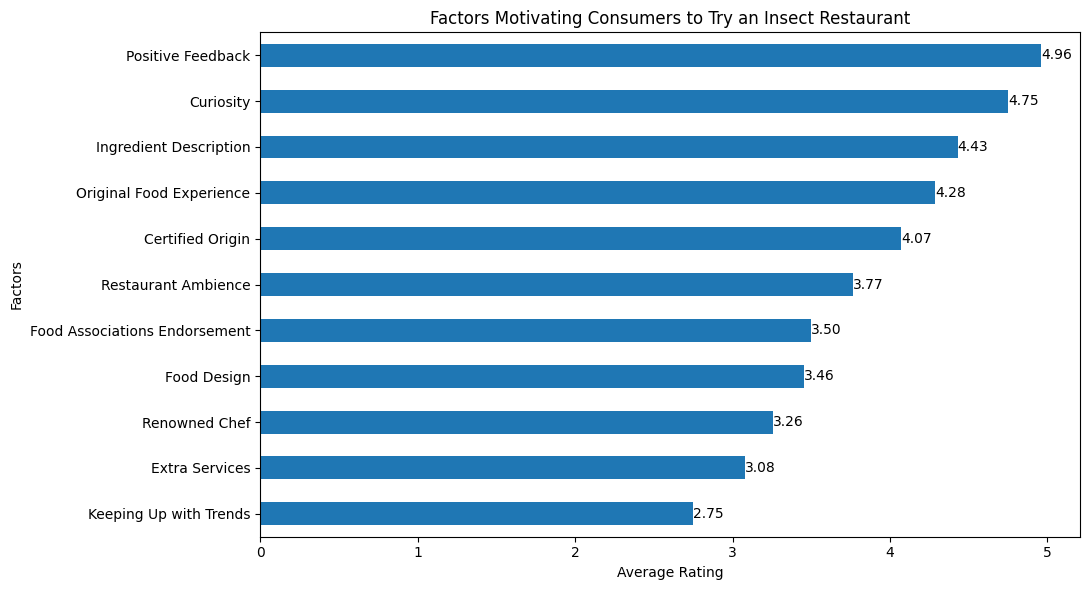

In [135]:
q14_labels = {
    'Q14_1': 'Curiosity',
    'Q14_2': 'Original Food Experience',
    'Q14_3': 'Certified Origin',
    'Q14_4': 'Renowned Chef',
    'Q14_5': 'Restaurant Ambience',
    'Q14_6': 'Positive Feedback',
    'Q14_7': 'Ingredient Description',
    'Q14_8': 'Food Associations Endorsement',
    'Q14_9': 'Extra Services',
    'Q14_10': 'Keeping Up with Trends',
    'Q14_11': 'Food Design'
}


q14_means = df[list(q14_labels.keys())].mean()

q14_means.index = [q14_labels[col] for col in q14_means.index]

q14_means = q14_means.sort_values()


plt.figure(figsize=(11,6))

ax = q14_means.plot(kind='barh')

plt.title('Factors Motivating Consumers to Try an Insect Restaurant')
plt.xlabel('Average Rating')
plt.ylabel('Factors')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

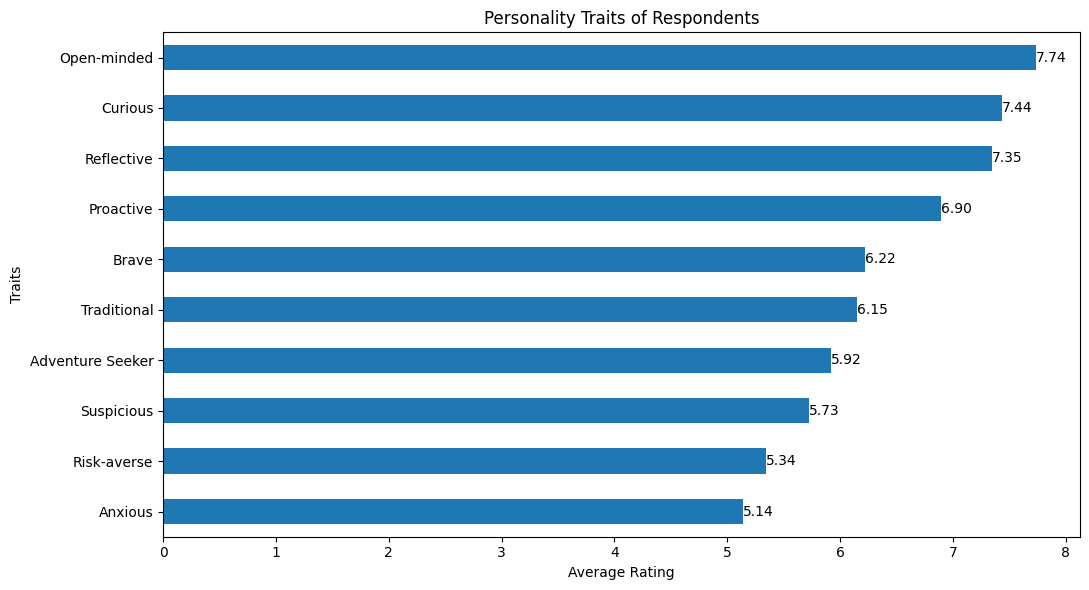

In [136]:
q17_labels = {
    'Q17_1': 'Curious',
    'Q17_2': 'Traditional',
    'Q17_3': 'Brave',
    'Q17_4': 'Anxious',
    'Q17_5': 'Open-minded',
    'Q17_6': 'Reflective',
    'Q17_7': 'Adventure Seeker',
    'Q17_8': 'Suspicious',
    'Q17_9': 'Proactive',
    'Q17_10': 'Risk-averse'
}


q17_means = df[list(q17_labels.keys())].mean()

q17_means.index = [q17_labels[col] for col in q17_means.index]

q17_means = q17_means.sort_values()


plt.figure(figsize=(11,6))

ax = q17_means.plot(kind='barh')

plt.title('Personality Traits of Respondents')
plt.xlabel('Average Rating')
plt.ylabel('Traits')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

# BIVARIATE RESEARCH

# Age Group vs Willingness to try Novel Food

/tmp/ipykernel_1086/2030511551.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals_per_age_group = df.groupby('Age_Group')['Q13_Label'].count()


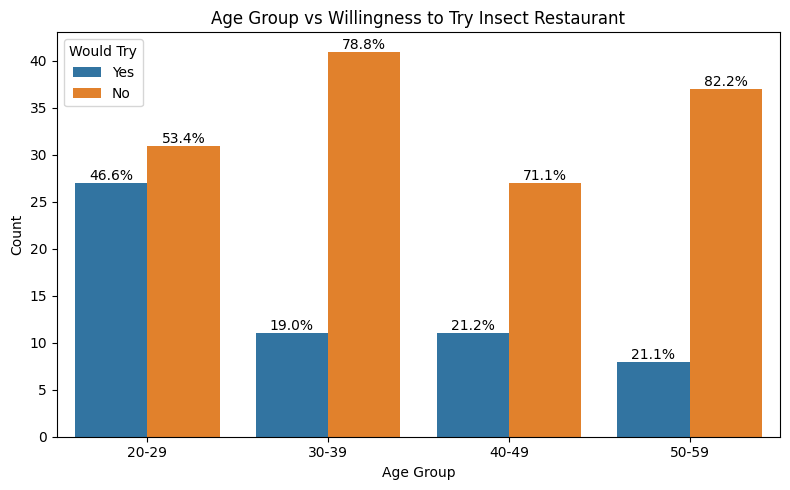

In [137]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Age_Group',
    hue='Q13_Label'
)

plt.title('Age Group vs Willingness to Try Insect Restaurant')
plt.xlabel('Age Group')
plt.ylabel('Count')

# Calculate totals for each Age_Group for percentage calculation
totals_per_age_group = df.groupby('Age_Group')['Q13_Label'].count()

for container in ax.containers:
    for p in container:
        height = p.get_height()
        # Get the Age_Group for the current bar
        age_group = p.get_x() + p.get_width() / 2 # approximate x-coordinate
        # Find the correct age group label from the x-tick labels
        age_group_label = ax.get_xticklabels()[int(age_group)].get_text()

        # Use the total for this specific age group as the denominator
        total_for_group = totals_per_age_group.get(age_group_label, 0)

        if total_for_group > 0:
            percentage = '{:.1f}%'.format(100 * height / total_for_group)
            x_offset = p.get_x() + p.get_width() / 2
            y_offset = height # Position y at the top of the bar
            ax.annotate(percentage, (x_offset, y_offset), ha='center', va='bottom')

plt.legend(title='Would Try')

plt.tight_layout()
plt.show()

# Novel Food Awareness vs Willingness to Try

<Figure size 1400x800 with 0 Axes>

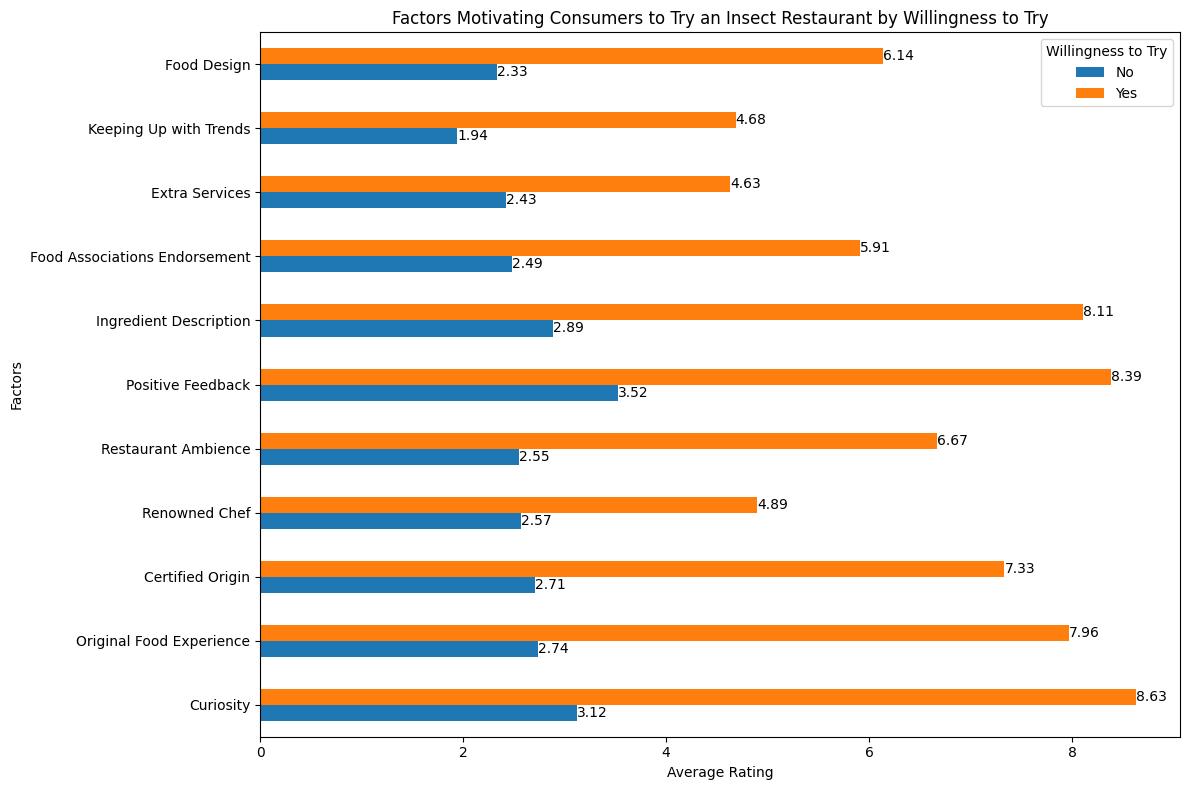

In [138]:
q14_willingness_means = df.groupby('Q13_Label')[list(q14_labels.keys())].mean()

plt.figure(figsize=(14, 8))

q14_willingness_means_T = q14_willingness_means.T
q14_willingness_means_T.index = [q14_labels[col] for col in q14_willingness_means_T.index]

ax = q14_willingness_means_T.plot(kind='barh', figsize=(12, 8))

plt.title('Factors Motivating Consumers to Try an Insect Restaurant by Willingness to Try')
plt.xlabel('Average Rating')
plt.ylabel('Factors')
plt.legend(title='Willingness to Try')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Area of Origin vs Willingness to Try

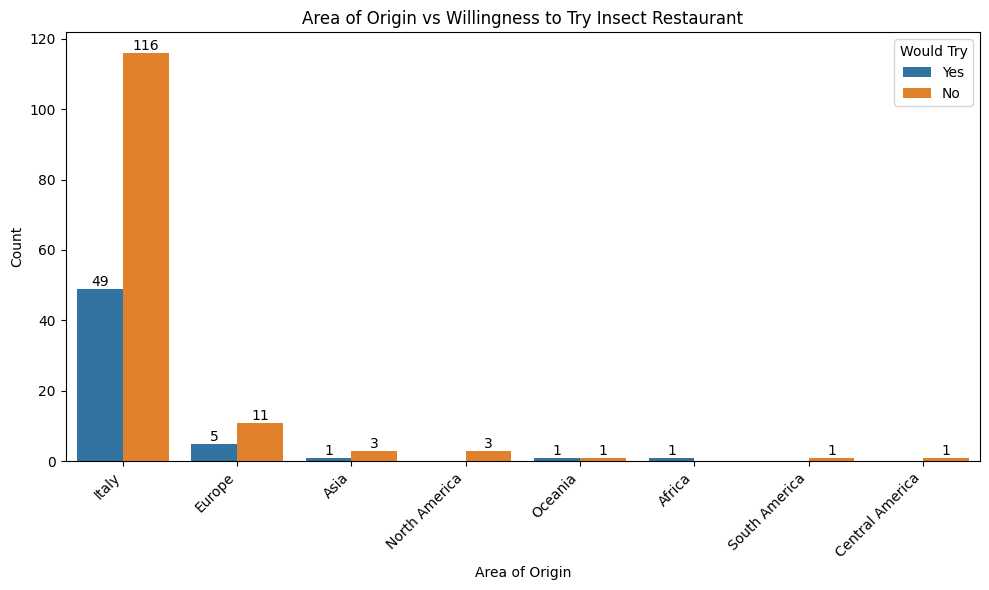

In [139]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='Q22',
    hue='Q13_Label',
    order=df['Q22'].value_counts().index
)

plt.title('Area of Origin vs Willingness to Try Insect Restaurant')
plt.xlabel('Area of Origin')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha='right')
plt.legend(title='Would Try')

plt.tight_layout()
plt.show()

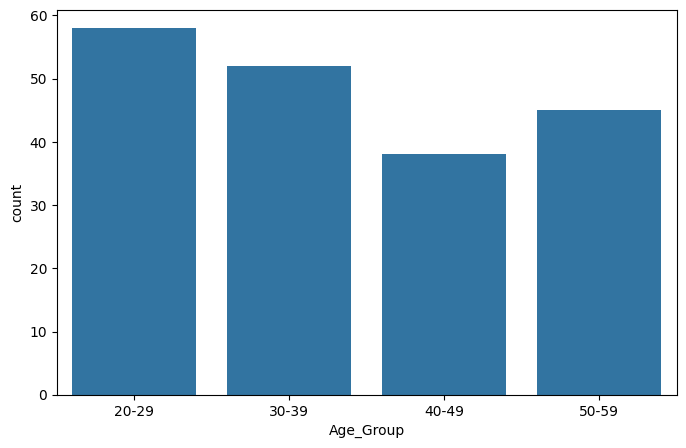

In [140]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Age_Group'
)

#Chi squared test, Cramer's V and logistical representation

In [141]:
import scipy.stats as stats
import numpy as np

# Creating table with age group and label
cross_table = pd.crosstab(df['Age_Group'], df['Q13_Label'])

# Calculate row-wise percentages
percentages = cross_table.apply(lambda r: r / r.sum(), axis=1).round(3)

# Create a multi-level column index for combined table
combined_columns = pd.MultiIndex.from_product([cross_table.columns, ['Count', 'Percentage']])

# Create a new DataFrame to hold combined data
combined_table = pd.DataFrame(index=cross_table.index, columns=combined_columns)

for col_name in cross_table.columns:
    combined_table[(col_name, 'Count')] = cross_table[col_name]
    combined_table[(col_name, 'Percentage')] = percentages[col_name]

print("Combined Table (Counts and Percentages within Age Group):")
display(combined_table)

Combined Table (Counts and Percentages within Age Group):


Q13_Label    No              Yes           
          Count Percentage Count Percentage
Age_Group                                  
20-29        31      0.534    27      0.466
30-39        41      0.788    11      0.212
40-49        27      0.711    11      0.289
50-59        37      0.822     8      0.178

In [142]:
# Creating table with age group and label
cross_table = pd.crosstab(df['Age_Group'], df['Q13_Label'])

# Calculate row-wise percentages
percentages = cross_table.apply(lambda r: r / r.sum(), axis=1).round(3)

# Create a multi-level column index for combined table
combined_columns = pd.MultiIndex.from_product([cross_table.columns, ['Count', 'Percentage']])

# Create a new DataFrame to hold combined data
combined_table = pd.DataFrame(index=cross_table.index, columns=combined_columns)

for col_name in cross_table.columns:
    combined_table[(col_name, 'Count')] = cross_table[col_name]
    combined_table[(col_name, 'Percentage')] = percentages[col_name]

print("Combined Table (Counts and Percentages within Age Group):")
display(combined_table)

Combined Table (Counts and Percentages within Age Group):


Q13_Label    No              Yes           
          Count Percentage Count Percentage
Age_Group                                  
20-29        31      0.534    27      0.466
30-39        41      0.788    11      0.212
40-49        27      0.711    11      0.289
50-59        37      0.822     8      0.178

In [143]:
# Calculate the chi-squared statistic
X2, p_value, degrees_of_freedom, expected_frequencies = stats.chi2_contingency(cross_table)
# print(X2, p_value, degrees_of_freedom)
# # Calculate Cramer's V
# N = np.sum(cross_table).sum()
# minimum_dimension = min(cross_table.shape) - 1
# cramers_v = np.sqrt(X2 / (N * minimum_dimension))

print(f"Chi-squared statistic (X2): {X2:.3f}")
print(f"Degrees of freedom : {degrees_of_freedom}")
print(f"P-value: {p_value}")

# print(f"Cramer's V index: {cramers_v:.3f}")

Chi-squared statistic (X2): 12.821
Degrees of freedom : 3
P-value: 0.005041173932459627


In [144]:

# Finding sample size, and minimum of rows and columns
N = cross_table.sum().sum() # Ensure N is a scalar representing the total count
minimum_dimension = min(cross_table.shape)-1

# Calculate Cramer's V (corrected formula)
result = np.sqrt(X2 / (N * minimum_dimension))

# Print the result
print(f'Cramer V index : {result:.3f}')

Cramer V index : 0.258


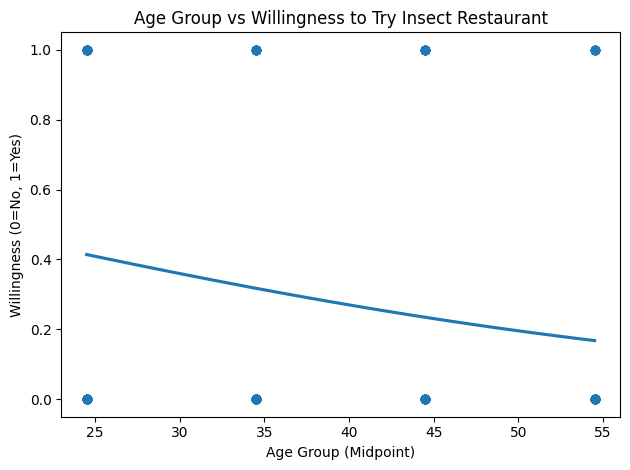

In [145]:
# Create a numerical version of Q13_Label
q13_numeric_map = {'No': 0, 'Yes': 1}
df['Q13_Numeric'] = df['Q13_Label'].map(q13_numeric_map)

# Create a numerical version of Age_Group using midpoints
age_group_numeric_map = {
    '20-29': 24.5,
    '30-39': 34.5,
    '40-49': 44.5,
    '50-59': 54.5
}
df['Age_Group_Numeric'] = df['Age_Group'].map(age_group_numeric_map)

sns.regplot(x=df['Age_Group_Numeric'], y=df['Q13_Numeric'],
            logistic=True, ci=None)

plt.title('Age Group vs Willingness to Try Insect Restaurant')
plt.xlabel('Age Group (Midpoint)')
plt.ylabel('Willingness (0=No, 1=Yes)')

# Removed plt.legend as it's not directly applicable for a single regplot line.

plt.tight_layout()
plt.show()

In [146]:
# Extract Q16 values for each Q13_Label group
q16_no = df[df['Q13_Label'] == 'No']['Q16']
q16_yes = df[df['Q13_Label'] == 'Yes']['Q16']

# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(q16_no, q16_yes)

print(f"F-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value}")



F-statistic: 61.843
P-value: 2.6685861989784325e-13


### Visualizing the Relationship between Q16 and Q13_Label (as described by Eta Squared)

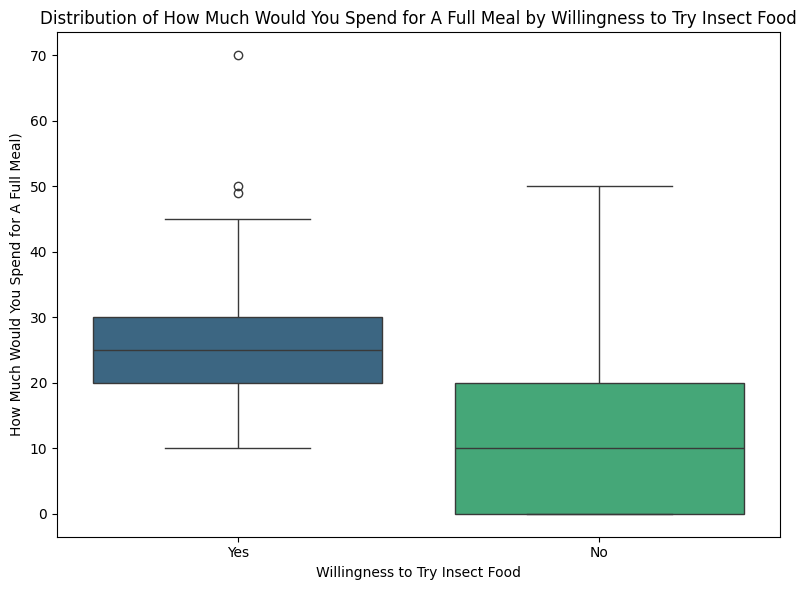

In [147]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Q13_Label', y='Q16', data=df, hue='Q13_Label', palette='viridis', legend=False)
plt.title('Distribution of How Much Would You Spend for A Full Meal by Willingness to Try Insect Food')
plt.xlabel('Willingness to Try Insect Food')
plt.ylabel('How Much Would You Spend for A Full Meal)')
plt.tight_layout()
plt.show()

# Clustering Algorithm


In [148]:
selected_col = [
    'Q1_3','Q1_4',
    'Q2_3','Q2_4',
    'Q4',
    'Q5',
    'Q16'
]

usate = [col for col in selected_col if col in df.columns]


final_data = df[usate]
print(final_data.head())

   Q1_3  Q1_4  Q2_3  Q2_4   Q4  Q5   Q16
0     8    10     9    10  2.0  25  25.0
1     8     9     6     8  3.0  25  25.0
2     6    10     8     9  2.0  35  20.0
3     5     9     3     2  0.0  40   5.0
4     5     9     6     6  2.0  25  25.0


In [149]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Handle potential missing values by dropping them or imputing. For this example, we'll drop.
# It's good practice to ensure no NaNs before scaling and clustering.
final_data_cleaned = final_data.dropna()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_data_cleaned)

# Calculate total number of observations for percentage calculation
total_observations = len(final_data_cleaned)

# Perform K-Means for k from 3 to 6
for n_clusters in range(3, 7):
    print(f"\n--- K-Means Clustering with {n_clusters} Clusters ---")

    # Initialize KMeans
    # n_init='auto' is used to suppress a future warning and is the recommended default.
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')

    # Fit the model and get cluster labels
    kmeans.fit(scaled_data)
    cluster_labels = kmeans.labels_

    # Add cluster labels to a temporary DataFrame for frequency calculation
    temp_df = final_data_cleaned.copy()
    temp_df['Cluster'] = cluster_labels

    # Get and print frequency distribution with percentages
    cluster_frequencies = temp_df['Cluster'].value_counts().sort_index()
    print("Distribution of observations per cluster (Count and Percentage):")
    for cluster_id, count in cluster_frequencies.items():
        percentage = (count / total_observations) * 100
        print(f"Cluster {cluster_id}: {count} ({percentage:.2f}%)")
    print("\n")


--- K-Means Clustering with 3 Clusters ---
Distribution of observations per cluster (Count and Percentage):
Cluster 0: 118 (61.14%)
Cluster 1: 50 (25.91%)
Cluster 2: 25 (12.95%)



--- K-Means Clustering with 4 Clusters ---
Distribution of observations per cluster (Count and Percentage):
Cluster 0: 109 (56.48%)
Cluster 1: 41 (21.24%)
Cluster 2: 26 (13.47%)
Cluster 3: 17 (8.81%)



--- K-Means Clustering with 5 Clusters ---
Distribution of observations per cluster (Count and Percentage):
Cluster 0: 69 (35.75%)
Cluster 1: 24 (12.44%)
Cluster 2: 27 (13.99%)
Cluster 3: 22 (11.40%)
Cluster 4: 51 (26.42%)



--- K-Means Clustering with 6 Clusters ---
Distribution of observations per cluster (Count and Percentage):
Cluster 0: 61 (31.61%)
Cluster 1: 24 (12.44%)
Cluster 2: 25 (12.95%)
Cluster 3: 23 (11.92%)
Cluster 4: 54 (27.98%)
Cluster 5: 6 (3.11%)




In [150]:
from scipy.stats import f_oneway

# Re-using final_data_cleaned and scaled_data from the previous cell

# Perform K-Means for k from 4 to 6 and then ANOVA
for n_clusters in range(4, 7):
    print(f"\n=== ANOVA for K-Means with {n_clusters} Clusters ===")

    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')

    # Fit the model and get cluster labels
    kmeans.fit(scaled_data)
    cluster_labels = kmeans.labels_

    # Add cluster labels to the original (cleaned) DataFrame
    df_with_clusters = final_data_cleaned.copy()
    df_with_clusters['Cluster'] = cluster_labels

    print("One-way ANOVA for each feature across clusters:")
    for column in final_data_cleaned.columns: # Iterate through original features
        # Prepare data for ANOVA: list of arrays, one for each cluster
        cluster_groups_data = []
        for i in range(n_clusters):
            cluster_groups_data.append(df_with_clusters[df_with_clusters['Cluster'] == i][column].dropna().values)

        # Perform one-way ANOVA
        f_statistic, p_value = f_oneway(*cluster_groups_data)

        print(f"  Feature '{column}': F-statistic = {f_statistic:.3f}, p-value = {p_value:.3f}")
        if p_value < 0.05:
            print(f"    (Statistically significant difference across clusters for '{column}')")
        else:
            print(f"    (No statistically significant difference across clusters for '{column}')")



=== ANOVA for K-Means with 4 Clusters ===
One-way ANOVA for each feature across clusters:
  Feature 'Q1_3': F-statistic = 17.587, p-value = 0.000
    (Statistically significant difference across clusters for 'Q1_3')
  Feature 'Q1_4': F-statistic = 81.669, p-value = 0.000
    (Statistically significant difference across clusters for 'Q1_4')
  Feature 'Q2_3': F-statistic = 44.811, p-value = 0.000
    (Statistically significant difference across clusters for 'Q2_3')
  Feature 'Q2_4': F-statistic = 24.985, p-value = 0.000
    (Statistically significant difference across clusters for 'Q2_4')
  Feature 'Q4': F-statistic = 6.562, p-value = 0.000
    (Statistically significant difference across clusters for 'Q4')
  Feature 'Q5': F-statistic = 14.772, p-value = 0.000
    (Statistically significant difference across clusters for 'Q5')
  Feature 'Q16': F-statistic = 39.705, p-value = 0.000
    (Statistically significant difference across clusters for 'Q16')

=== ANOVA for K-Means with 5 Clusters

In [151]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Ensure final_data_cleaned and scaled_data are available from previous execution
# If not, uncomment and run the following lines:
# file_path = '/content/Novel_Food_Dataset.xlsx'
# data = pd.read_excel(file_path, header=0)
# selected_col = ['Q1_3','Q1_4','Q2_3','Q2_4','Q4','Q5','Q16']
# usate = [col for col in selected_col if col in data.columns]
# final_data = data[usate]
# final_data_cleaned = final_data.dropna()
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(final_data_cleaned)

# Perform K-Means with 5 clusters
n_clusters = 5
kmeans_5_clusters = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
kmeans_5_clusters.fit(scaled_data)

# Get the standardized centroids
centroids_standardized = pd.DataFrame(
    kmeans_5_clusters.cluster_centers_,
    columns=final_data_cleaned.columns,
    index=[f'Cluster {i}' for i in range(n_clusters)]
)

# Define the styling function
def highlight_centroid_values(s):
    is_max = s.nlargest(2).index
    is_min = s.nsmallest(2).index
    is_mid = s.drop(is_max).drop(is_min).nlargest(3).index # Get the remaining 3 as intermediate

    colors = []
    for val_index in s.index:
        if val_index in is_max:
            colors.append('background-color: lightgreen') # Green for top 2
        elif val_index in is_min:
            colors.append('background-color: lightcoral')  # Red for bottom 2
        elif val_index in is_mid:
            colors.append('background-color: lightyellow') # Yellow for middle 3
        else:
            colors.append('')
    return colors

print(f"\n--- Standardized Centroids for {n_clusters} Clusters with Highlighted Values ---\n")
styled_centroids = centroids_standardized.style.apply(highlight_centroid_values, axis=0)
display(styled_centroids)


--- Standardized Centroids for 5 Clusters with Highlighted Values ---



,Q1_3,Q1_4,Q2_3,Q2_4,Q4,Q5,Q16
Cluster 0,0.273072,0.263118,0.861017,0.475348,0.031487,-0.234377,-0.434898
Cluster 1,-0.666414,0.409886,-1.010803,-0.596969,0.192238,0.960225,-0.969920
Cluster 2,-0.828961,-0.095649,0.055066,0.217734,0.880489,0.768086,1.450297
Cluster 3,-0.585745,-1.764950,-0.950418,-1.039799,-0.377882,-0.600517,-0.233159
Cluster 4,0.635692,0.263118,-0.308402,-0.028922,-0.436197,-0.282361,0.377598


In [152]:
import pandas as pd

# Add cluster labels to the main DataFrame 'df'
# The cluster labels (kmeans_5_clusters.labels_) correspond to the rows in 'final_data_cleaned',
# which has the same index as 'df' (193 rows each).
df_clustered = df.copy()
df_clustered['Cluster'] = kmeans_5_clusters.labels_

# Columns for which distributions are requested
analysis_columns = {
    'Q20': 'Gender',        # Mapped to Male/Female
    'Age_Group': 'Age',     # Derived from Q19 into age groups
    'Q27': 'Occupation'     # Mapped to Student/Part Time/etc.
}

# Clusters to analyze - added cluster 3
target_clusters = [0, 1, 2, 3, 4]

print("--- Distribution Analysis for Selected Clusters ---\n")

# Iterate through each target cluster
for cluster_id in target_clusters:
    print(f"### Cluster {cluster_id}\n")
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]

    # Iterate through each analysis column (Gender, Age, Occupation)
    for col_name, display_name in analysis_columns.items():
        print(f"Distribution of {display_name} (Column: {col_name}):")

        # Calculate value counts
        # dropna=False ensures that NaN values, if any, are counted.
        counts = cluster_data[col_name].value_counts(dropna=False)
        total_count = counts.sum()

        if total_count == 0:
            print("  No data for this cluster in this column.\n")
            continue

        # Calculate percentages
        percentages = cluster_data[col_name].value_counts(normalize=True, dropna=False) * 100

        # Combine counts and percentages into a single DataFrame for display
        distribution_df = pd.DataFrame({
            'Count': counts,
            'Percentage': percentages
        }).sort_index() # Sort by index for consistent output order

        # Format percentages to 2 decimal places for readability
        distribution_df['Percentage'] = distribution_df['Percentage'].map('{:.2f}%'.format)

        display(distribution_df)
        print("\n")

print("Note: Q20 represents Gender, Age_Group represents Age (derived from Q19), and Q27 represents Occupation, based on previous data mappings.")

--- Distribution Analysis for Selected Clusters ---

### Cluster 0

Distribution of Gender (Column: Q20):


,Count,Percentage
Q20,,
Female,45,65.22%
Male,24,34.78%




Distribution of Age (Column: Age_Group):


,Count,Percentage
Age_Group,,
20-29,29,42.03%
30-39,20,28.99%
40-49,10,14.49%
50-59,10,14.49%




Distribution of Occupation (Column: Q27):


...



Distribution of Age (Column: Age_Group):


,Count,Percentage
Age_Group,,
20-29,14,27.45%
30-39,18,35.29%
40-49,7,13.73%
50-59,12,23.53%




Distribution of Occupation (Column: Q27):


,Count,Percentage
Q27,,
Full Time,31,60.78%
Part Time,9,17.65%
Retired,2,3.92%
Student,7,13.73%
Unemployed,2,3.92%




Note: Q20 represents Gender, Age_Group represents Age (derived from Q19), and Q27 represents Occupation, based on previous data mappings.
